<a href="https://colab.research.google.com/github/Tar-ive/dl_basics/blob/main/Linear_Regression_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implement Linear Regression In PyTorch

In [1]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from torch.utils.data import DataLoader, Dataset
from matplotlib import pyplot as plt

In [2]:
#Generate Synthetic Data
torch.manual_seed(42)
X = torch.rand(100,1) * 10 # generates random values (100 of them) from 0-10
y = 2 * X + 3 + torch.randn(100,1) # Linear Relationship with the Noise

#Save data to Csv File
data = torch.cat((X,y), dim = 1)
df = pd.DataFrame(data.numpy(), columns = ["X", "y"])
df.to_csv("data.csv", index = False)

In [3]:
# Write the Custom Dataset Class
class LinearRegressionDataset(Dataset):
  def __init__(self, csv_file):
    # Load data from csv file
    self.data = pd.read_csv(csv_file)
    self.X = torch.tensor(self.data["X"].values, dtype=torch.float32).view(-1,1 )
    self.y = torch.tensor(self.data["y"].values, dtype=torch.float32).view(-1,1 )

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]


#Example usage of DataLoader
dataset = LinearRegressionDataset("data.csv")
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [4]:
# Define Linear Regression Model
class CustomActivationLinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__() # calls base class nn.Module
    self.linear = nn.Linear(1,1)

  def custom_activation(self,x):
    activation = torch.tanh(x) + x
    return activation

# Define Forward Pass
  def forward(self, X):
    return self.custom_activation(self.linear(X))

In [6]:
# Custom Loss function - Huber Loss
class HuberLoss(nn.Module):
  def __init__(self, delta = 1.0):
    super().__init__()
    self.delta = delta

  def forward(self, y_pred, y_true):
    #Calculate absolute error
    error = torch.abs(y_pred - y_true)

    #Apply the huber loss formula
    loss = torch.where(error <=self.delta,
                       0.5 * error **2,
                       self.delta * (error - 0.5 * self.delta))
    return loss.mean()



In [7]:
#Initialize Model, Loss Function (MSELoss) and Optimizer (SGD)
model = CustomActivationLinearRegressionModel()
criterion = nn.HuberLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [8]:
#Training Loop
epochs = 1000
for epoch in range(epochs):
  for batch_X, batch_y in dataloader:
    #Forward pass
    predictions = model(batch_X)
    loss = criterion(predictions, batch_y)

    #Backward Pass and Optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  #Log Progress every 100 epochs
  if (epoch+1) % 100 == 0:
    print(f"Epoch:[{epoch+1}/{epochs}], loss:{loss.item():.4f}")

Epoch:[100/1000], loss:0.5335
Epoch:[200/1000], loss:0.2743
Epoch:[300/1000], loss:0.6435
Epoch:[400/1000], loss:0.1679
Epoch:[500/1000], loss:0.2730
Epoch:[600/1000], loss:0.6405
Epoch:[700/1000], loss:0.4294
Epoch:[800/1000], loss:0.1416
Epoch:[900/1000], loss:0.2735
Epoch:[1000/1000], loss:0.5794


Learned weight: 1.9493, Learned Bias:2.2974


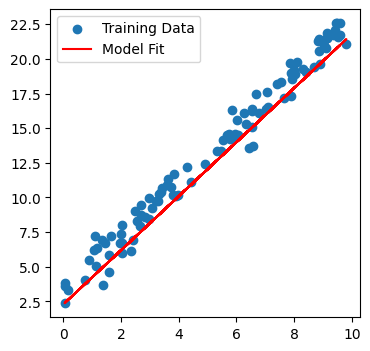

In [9]:
#Display the Learned Parameters
[W, b]= model.linear.parameters()
print(f"Learned weight: {W.item():.4f}, Learned Bias:{b.item():.4f}")

# Plot the model fit to the train data
plt.figure(figsize=(4, 4))
plt.scatter(X, y, label='Training Data')
plt.plot(X, W.item()*X + b.item(), 'r', label='Model Fit')
plt.legend()
plt.show()

In [10]:
#Testing on New Data
X_test = torch.tensor([[4.0], [7.0]])


with torch.no_grad():
  predictions = model(X_test)
  print(f"Predictions for {X_test.tolist()}:{predictions.tolist()}")

Predictions for [[4.0], [7.0]]:[[11.094761848449707], [16.942798614501953]]
